In [1]:
!pip install -q torch transformers accelerate sentencepiece python-dotenv pandas matplotlib openai google-generativeai ipywidgets

In [2]:
import os
import time
import gc
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch

from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

load_dotenv()

if torch.cuda.is_available():
    DEVICE = "cuda"

elif torch.backends.mps.is_available():
    DEVICE = "mps"

else:
    DEVICE = "cpu"

print("Device:", DEVICE)

Device: mps


In [3]:
def clear_memory():
    gc.collect()

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [4]:
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print("Tokenizer downloaded:", MODEL_ID)

clear_memory()

Tokenizer downloaded: Qwen/Qwen2.5-0.5B-Instruct


In [5]:
MODEL_CATALOG = {
    "Ultra-Light (<1B)": [
        "HuggingFaceTB/SmolLM2-135M-Instruct",
        "HuggingFaceTB/SmolLM2-360M-Instruct",
        "Qwen/Qwen2.5-0.5B-Instruct",
    ],
    "Small (1B-3B)": [
        "meta-llama/Llama-3.2-1B-Instruct",
        "HuggingFaceTB/SmolLM2-1.7B-Instruct",
        "google/gemma-2-2b-it",
    ],
    "Medium (3B-7B)": [
        "meta-llama/Llama-3.2-3B-Instruct",
        "Qwen/Qwen2.5-3B-Instruct",
        "microsoft/Phi-3.5-mini-instruct",
    ],
    "Large (7B-13B)": [
        "mistralai/Mistral-7B-Instruct-v0.3",
        "Qwen/Qwen2.5-7B-Instruct",
        "meta-llama/Llama-3.1-8B-Instruct",
    ],
    "XL (14B-32B)": [
        "Qwen/Qwen2.5-14B-Instruct",
        "google/gemma-2-27b-it",
        "Qwen/Qwen2.5-32B-Instruct",
    ],
}

all_models = [m for models in MODEL_CATALOG.values() for m in models]

for category, models in MODEL_CATALOG.items():
    print(f"\n{category}")

    for model_name in models:
        print(" -", model_name)

print("\nTotal models listed:", len(all_models))


Ultra-Light (<1B)
 - HuggingFaceTB/SmolLM2-135M-Instruct
 - HuggingFaceTB/SmolLM2-360M-Instruct
 - Qwen/Qwen2.5-0.5B-Instruct

Small (1B-3B)
 - meta-llama/Llama-3.2-1B-Instruct
 - HuggingFaceTB/SmolLM2-1.7B-Instruct
 - google/gemma-2-2b-it

Medium (3B-7B)
 - meta-llama/Llama-3.2-3B-Instruct
 - Qwen/Qwen2.5-3B-Instruct
 - microsoft/Phi-3.5-mini-instruct

Large (7B-13B)
 - mistralai/Mistral-7B-Instruct-v0.3
 - Qwen/Qwen2.5-7B-Instruct
 - meta-llama/Llama-3.1-8B-Instruct

XL (14B-32B)
 - Qwen/Qwen2.5-14B-Instruct
 - google/gemma-2-27b-it
 - Qwen/Qwen2.5-32B-Instruct

Total models listed: 15


In [6]:
RUNNABLE_MODELS = [
    "HuggingFaceTB/SmolLM2-135M-Instruct",
    "HuggingFaceTB/SmolLM2-360M-Instruct",
    "Qwen/Qwen2.5-0.5B-Instruct",
    "HuggingFaceTB/SmolLM2-1.7B-Instruct",
]

RUNNABLE_MODELS

['HuggingFaceTB/SmolLM2-135M-Instruct',
 'HuggingFaceTB/SmolLM2-360M-Instruct',
 'Qwen/Qwen2.5-0.5B-Instruct',
 'HuggingFaceTB/SmolLM2-1.7B-Instruct']

In [7]:
TEST_CASES = [
    {
        "name": "messy_professor_email",
        "context": "Professional Email",
        "tone": "Polite",
        "input_text": (
            "hey professor i was sick and missed class and i wanted to ask if i can "
            "make up the quiz sometime this week sorry for the inconvenience"
        ),
    },
    {
        "name": "awkward_job_followup",
        "context": "Professional Email",
        "tone": "Professional",
        "input_text": (
            "hi i just wanted to follow up again on the internship because i am very "
            "interested and i think it would be a great fit for me and i would love to hear back soon"
        ),
    },
    {
        "name": "rough_academic_paragraph",
        "context": "Academic Writing",
        "tone": "Clear",
        "input_text": (
            "social media affects students in many ways and sometimes it is good but also bad "
            "because it helps communication but also wastes time and makes people compare themselves too much"
        ),
    },
    {
        "name": "wordy_message",
        "context": "General Rewrite",
        "tone": "Clear",
        "input_text": (
            "I just kind of wanted to maybe ask whether it might be possible for you to perhaps "
            "send me the updated file whenever you get a chance because I was not sure if the current "
            "one is the most recent one or not"
        ),
    },
]

In [8]:
def build_rewrite_prompt(input_text, context, tone, mode="zero_shot"):
    system = (
        "You are a professional human editor. "
        "Rewrite text so it sounds natural, concise, and context-appropriate. "
        "Do not sound like a chatbot. Avoid filler, clichés, and generic AI phrasing. "
        "Preserve all important facts and intent."
    )

    base_user = f"""
Context: {context}
Tone: {tone}

Task:
Rewrite the text so it reads like something a real person would actually send or submit.
Keep the meaning, improve clarity and structure, and avoid AI-sounding fluff.

Return only the rewritten text.

Original text:
{input_text}
""".strip()

    if mode == "zero_shot":
        return system, base_user

    if mode == "one_shot":
        example = """
Example:
Original: hey i missed class today because i got sick can i make it up later this week
Rewrite: Hello Professor, I was sick today and missed class. Would it be possible to make up the work later this week?
""".strip()
        return system, example + "\n\n" + base_user

    if mode == "few_shot":
        examples = """
Example 1:
Original: hey i missed class today because i got sick can i make it up later this week
Rewrite: Hello Professor, I was sick today and missed class. Would it be possible to make up the work later this week?

Example 2:
Original: i just wanted to follow up because i am still interested in the position
Rewrite: I wanted to follow up and reiterate my interest in the position.

Example 3:
Original: social media is good and bad for students for different reasons
Rewrite: Social media has both positive and negative effects on students, depending on how it is used.
""".strip()
        return system, examples + "\n\n" + base_user

    if mode == "many_shot":
        examples = """
Example 1:
Original: hey i missed class today because i got sick can i make it up later this week
Rewrite: Hello Professor, I was sick today and missed class. Would it be possible to make up the work later this week?

Example 2:
Original: i just wanted to follow up because i am still interested in the position
Rewrite: I wanted to follow up and reiterate my interest in the position.

Example 3:
Original: social media is good and bad for students for different reasons
Rewrite: Social media has both positive and negative effects on students, depending on how it is used.

Example 4:
Original: can you send me the latest file when you can
Rewrite: Could you please send me the latest version of the file when you have a chance?

Example 5:
Original: i think the article shows that exercise helps memory in older adults
Rewrite: The article suggests that exercise may help improve memory in older adults.
""".strip()
        return system, examples + "\n\n" + base_user

    raise ValueError("Invalid mode")

In [9]:
def load_text_gen_pipeline(model_id):
    clear_memory()

    local_tokenizer = AutoTokenizer.from_pretrained(model_id)

    local_model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.float16 if DEVICE == "mps" else "auto",
        low_cpu_mem_usage=True
    ).to(DEVICE)

    return pipeline(
        "text-generation",
        model=local_model,
        tokenizer=local_tokenizer,
    )

In [10]:
def generate_with_pipeline(pipe, system_prompt, user_prompt, max_new_tokens=100):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    output = pipe(
        messages,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.2,
        return_full_text=False
    )

    try:
        return output[0]["generated_text"][-1]["content"].strip()

    except Exception:
        return str(output)

In [11]:
AI_PHRASES = [
    "i hope this message finds you well",
    "i wanted to reach out",
    "please let me know if you have any questions",
    "thank you for your time and consideration",
]

def evaluate_output(original, rewritten):
    lowered = rewritten.lower()

    no_ai_fluff = int(not any(p in lowered for p in AI_PHRASES))
    shorter_or_similar = int(len(rewritten.split()) <= len(original.split()) * 1.25)
    has_sentence_end = int(rewritten.strip().endswith((".", "!", "?")))

    score_total = no_ai_fluff + shorter_or_similar + has_sentence_end

    return {
        "no_ai_fluff": no_ai_fluff,
        "shorter_or_similar": shorter_or_similar,
        "has_sentence_end": has_sentence_end,
        "score_total": score_total,
    }

In [12]:
pilot_models = [
    "Qwen/Qwen2.5-0.5B-Instruct",
    "HuggingFaceTB/SmolLM2-360M-Instruct",
    "HuggingFaceTB/SmolLM2-1.7B-Instruct",
]

pilot_rows = []

for model_id in pilot_models:
    print("Testing:", model_id)

    clear_memory()

    try:
        pipe = load_text_gen_pipeline(model_id)

        for case in TEST_CASES:
            system_prompt, user_prompt = build_rewrite_prompt(
                case["input_text"],
                case["context"],
                case["tone"],
                mode="zero_shot"
            )

            start = time.time()
            rewritten = generate_with_pipeline(pipe, system_prompt, user_prompt)
            latency = round(time.time() - start, 2)

            metrics = evaluate_output(case["input_text"], rewritten)

            pilot_rows.append({
                "model": model_id,
                "case": case["name"],
                "mode": "zero_shot",
                "latency_sec": latency,
                "output": rewritten,
                **metrics,
            })

        del pipe
        clear_memory()

    except Exception as e:
        pilot_rows.append({
            "model": model_id,
            "case": "LOAD_ERROR",
            "mode": "zero_shot",
            "latency_sec": None,
            "output": str(e),
            "score_total": -1,
        })
        clear_memory()

pilot_df = pd.DataFrame(pilot_rows)
pilot_df

Testing: Qwen/Qwen2.5-0.5B-Instruct


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set.

Testing: HuggingFaceTB/SmolLM2-360M-Instruct


...

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please

Testing: HuggingFaceTB/SmolLM2-1.7B-Instruct


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


,model,case,mode,latency_sec,output,no_ai_fluff,shorter_or_similar,has_sentence_end,score_total
0,Qwen/Qwen2.5-0.5B-Instruct,messy_professor_email,zero_shot,1.65,"[{'generated_text': 'Hey Professor, I got real...",1,1,0,2
1,Qwen/Qwen2.5-0.5B-Instruct,awkward_job_followup,zero_shot,1.09,"[{'generated_text': 'Hi, I just wanted to foll...",1,1,0,2
2,Qwen/Qwen2.5-0.5B-Instruct,rough_academic_paragraph,zero_shot,0.43,"[{'generated_text': ""I'm sorry, but I can't as...",1,1,0,2
3,Qwen/Qwen2.5-0.5B-Instruct,wordy_message,zero_shot,1.09,"[{'generated_text': ""I just wanted to inquire ...",1,1,0,2
4,HuggingFaceTB/SmolLM2-360M-Instruct,messy_professor_email,zero_shot,3.32,"[{'generated_text': 'Dear Professor,\n\nI hope...",0,0,0,0
5,HuggingFaceTB/SmolLM2-360M-Instruct,awkward_job_followup,zero_shot,4.12,"[{'generated_text': ""Dear [Recipient's Name],\...",0,0,0,0
6,HuggingFaceTB/SmolLM2-360M-Instruct,rough_academic_paragraph,zero_shot,5.43,[{'generated_text': 'Here\'s a rewritten versi...,1,0,0,1
7,HuggingFaceTB/SmolLM2-360M-Instruct,wordy_message,zero_shot,1.33,"[{'generated_text': ""I just wanted to ask if y...",1,1,0,2
8,HuggingFaceTB/SmolLM2-1.7B-Instruct,messy_professor_email,zero_shot,80.04,"[{'generated_text': ""Hi Professor,\n\nI hope y...",0,0,0,0
9,HuggingFaceTB/SmolLM2-1.7B-Instruct,awkward_job_followup,zero_shot,62.11,"[{'generated_text': ""Hi, I wanted to follow up...",1,0,0,1


In [13]:
pilot_summary = (
    pilot_df.groupby("model")[["score_total", "latency_sec"]]
    .mean()
    .sort_values(["score_total", "latency_sec"], ascending=[False, True])
)

pilot_summary

,score_total,latency_sec
model,,
Qwen/Qwen2.5-0.5B-Instruct,2.00,1.0650
HuggingFaceTB/SmolLM2-1.7B-Instruct,1.00,64.5425
HuggingFaceTB/SmolLM2-360M-Instruct,0.75,3.5500


In [14]:
def run_matrix(models, test_cases, mode="zero_shot"):
    rows = []

    for model_id in models:
        print("Running:", model_id)

        clear_memory()

        try:
            pipe = load_text_gen_pipeline(model_id)

            for case in test_cases:
                system_prompt, user_prompt = build_rewrite_prompt(
                    case["input_text"],
                    case["context"],
                    case["tone"],
                    mode=mode
                )

                start = time.time()
                rewritten = generate_with_pipeline(pipe, system_prompt, user_prompt)
                latency = round(time.time() - start, 2)

                metrics = evaluate_output(case["input_text"], rewritten)

                rows.append({
                    "model": model_id,
                    "case": case["name"],
                    "mode": mode,
                    "latency_sec": latency,
                    "output": rewritten,
                    **metrics,
                })

            del pipe
            clear_memory()

        except Exception as e:
            rows.append({
                "model": model_id,
                "case": "LOAD_ERROR",
                "mode": mode,
                "latency_sec": None,
                "output": str(e),
                "score_total": -1,
            })
            clear_memory()

    return pd.DataFrame(rows)

In [15]:
df_zero = run_matrix(RUNNABLE_MODELS, TEST_CASES, mode="zero_shot")
df_zero.head()

Running: HuggingFaceTB/SmolLM2-135M-Instruct


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running: HuggingFaceTB/SmolLM2-360M-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running: HuggingFaceTB/SmolLM2-1.7B-Instruct


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


,model,case,mode,latency_sec,output,no_ai_fluff,shorter_or_similar,has_sentence_end,score_total
0,HuggingFaceTB/SmolLM2-135M-Instruct,messy_professor_email,zero_shot,3.46,"[{'generated_text': ""Hey Professor,\n\nI hope ...",1,0,0,1
1,HuggingFaceTB/SmolLM2-135M-Instruct,awkward_job_followup,zero_shot,3.53,"[{'generated_text': ""Hi, I hope you're doing w...",1,0,0,1
2,HuggingFaceTB/SmolLM2-135M-Instruct,rough_academic_paragraph,zero_shot,4.77,[{'generated_text': 'Social media has a profou...,1,0,0,1
3,HuggingFaceTB/SmolLM2-135M-Instruct,wordy_message,zero_shot,3.72,"[{'generated_text': ""I just wanted to ask if y...",1,0,0,1
4,HuggingFaceTB/SmolLM2-360M-Instruct,messy_professor_email,zero_shot,3.35,"[{'generated_text': 'Dear Professor,\n\nI hope...",0,0,0,0


In [18]:
finalists = [
    "Qwen/Qwen2.5-0.5B-Instruct",
    "HuggingFaceTB/SmolLM2-360M-Instruct",
]

modes = ["zero_shot", "few_shot"]
route_a_rows = []

for model_id in finalists:
    print("Prompt strategy test:", model_id)

    clear_memory()

    try:
        pipe = load_text_gen_pipeline(model_id)

        print("Loaded successfully:", model_id)

        for mode in modes:
            for case in TEST_CASES:
                try:
                    system_prompt, user_prompt = build_rewrite_prompt(
                        case["input_text"],
                        case["context"],
                        case["tone"],
                        mode=mode
                    )

                    start = time.time()
                    rewritten = generate_with_pipeline(pipe, system_prompt, user_prompt)
                    latency = round(time.time() - start, 2)

                    metrics = evaluate_output(case["input_text"], rewritten)

                    route_a_rows.append({
                        "model": model_id,
                        "mode": mode,
                        "case": case["name"],
                        "latency_sec": latency,
                        "output": rewritten,
                        **metrics,
                    })
                except Exception as e:
                    route_a_rows.append({
                        "model": model_id,
                        "mode": mode,
                        "case": case["name"],
                        "latency_sec": None,
                        "output": f"GENERATION_ERROR: {str(e)}",
                        "score_total": -1,
                    })

        del pipe
        clear_memory()

    except Exception as e:
        route_a_rows.append({
            "model": model_id,
            "mode": "ERROR",
            "case": "LOAD_ERROR",
            "latency_sec": None,
            "output": str(e),
            "score_total": -1,
        })

        clear_memory()

route_a_df = pd.DataFrame(route_a_rows)
route_a_df.head()

Prompt strategy test: Qwen/Qwen2.5-0.5B-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded successfully: Qwen/Qwen2.5-0.5B-Instruct


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Prompt strategy test: HuggingFaceTB/SmolLM2-360M-Instruct


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded successfully: HuggingFaceTB/SmolLM2-360M-Instruct


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

,model,mode,case,latency_sec,output,no_ai_fluff,shorter_or_similar,has_sentence_end,score_total
0,Qwen/Qwen2.5-0.5B-Instruct,zero_shot,messy_professor_email,5.80,"[{'generated_text': 'Hey Professor, I got real...",1,1,0,2
1,Qwen/Qwen2.5-0.5B-Instruct,zero_shot,awkward_job_followup,1.50,"[{'generated_text': 'Hi, I just wanted to foll...",1,1,0,2
2,Qwen/Qwen2.5-0.5B-Instruct,zero_shot,rough_academic_paragraph,0.67,"[{'generated_text': ""I'm sorry, but I can't as...",1,1,0,2
3,Qwen/Qwen2.5-0.5B-Instruct,zero_shot,wordy_message,1.50,"[{'generated_text': ""I just wanted to inquire ...",1,1,0,2
4,Qwen/Qwen2.5-0.5B-Instruct,few_shot,messy_professor_email,2.41,"[{'generated_text': ""Hello Professor, I was si...",1,0,0,1


In [19]:
route_a_summary = (
    route_a_df.groupby(["model", "mode"])[["score_total", "latency_sec"]]
    .mean()
    .sort_values(["score_total", "latency_sec"], ascending=[False, True])
)

route_a_summary

score_total  latency_sec
model                               mode                               
Qwen/Qwen2.5-0.5B-Instruct          zero_shot         2.00       2.3675
                                    few_shot          1.50       1.7300
HuggingFaceTB/SmolLM2-360M-Instruct few_shot          1.50       1.8100
                                    zero_shot         0.75       3.8250

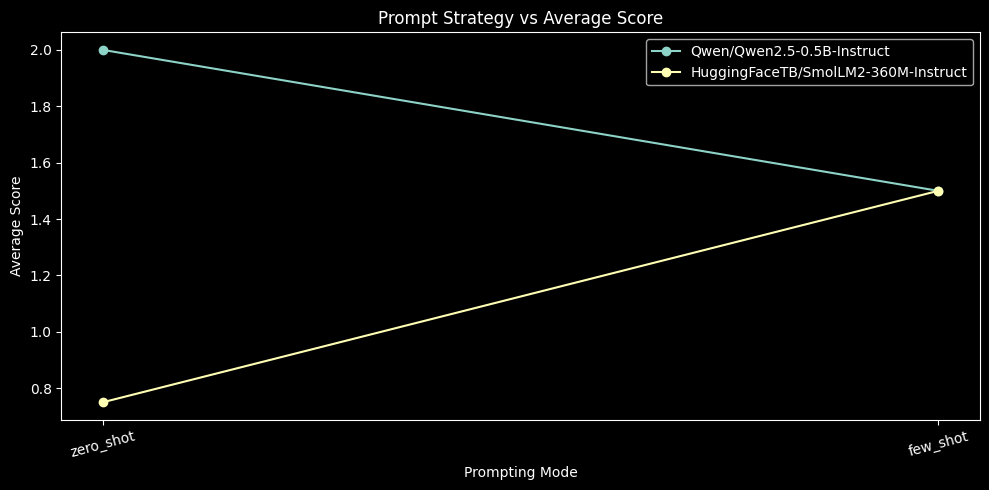

In [20]:
plot_df = route_a_summary.reset_index()

plt.figure(figsize=(10, 5))

for model_name in plot_df["model"].unique():
    subset = plot_df[plot_df["model"] == model_name]
    plt.plot(subset["mode"], subset["score_total"], marker="o", label=model_name)

plt.title("Prompt Strategy vs Average Score")
plt.xlabel("Prompting Mode")
plt.ylabel("Average Score")
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [21]:
Path("results").mkdir(exist_ok=True)

pilot_df.to_csv("results/pilot_results.csv", index=False)
df_zero.to_csv("results/runnable_zero_shot_results.csv", index=False)
route_a_df.to_csv("results/route_a_results.csv", index=False)

print("Saved notebook results to llm-test/results/")

Saved notebook results to llm-test/results/


In [22]:
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def rewrite_with_openai(text, context="Professional Email", tone="Polite"):
    prompt = f"""
You are a professional human editor.
Rewrite the text so it sounds natural, concise, and context-appropriate.
Avoid AI-sounding fluff, clichés, and generic phrasing.
Preserve all important facts and intent.

Context: {context}
Tone: {tone}

Original text:
{text}
""".strip()

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt
    )

    return response.output_text.strip()

In [23]:
sample_case = TEST_CASES[0]

openai_output = rewrite_with_openai(
    text=sample_case["input_text"],
    context=sample_case["context"],
    tone=sample_case["tone"]
)

print("Original:\n", sample_case["input_text"])
print("\nOpenAI Rewrite:\n", openai_output)

Original:
 hey professor i was sick and missed class and i wanted to ask if i can make up the quiz sometime this week sorry for the inconvenience

OpenAI Rewrite:
 Dear Professor,  

I was ill and missed class. Could I please arrange to make up the quiz sometime this week? I apologize for any inconvenience.  

Thank you.
